# Liquid-bearing cloud hours by LWP and surface class

Loads the ERA5 archive **once**, then draws each figure from that in-memory
state. The load cell is the only slow step -- `open_mfdataset` over the whole
region takes minutes -- and it only has to run again if you change the region,
season, years, or thresholds. Re-running a figure cell costs a second.

Everything here comes from `plot_lwp_histogram_by_surface_class.py` -- this
notebook holds no analysis code of its own, so the two cannot drift apart.
Editing the module and re-running a figure cell picks up the change
(autoreload is on).

| Cell | What it does |
|---|---|
| Load | `prepare()` -> an `Analysis` holding the surface classification, both bin scales, and every phase |
| Report | the numeric summary the command line prints |
| Figure 1 | linear LWP bins |
| Figure 2 | log-spaced LWP bins |

Both figures are drawn from the same accumulated cell-hours; only the bin
edges differ, so their bar totals agree exactly.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import plot_lwp_histogram_by_surface_class as lwph

# open_mfdataset warns about join/compat defaults changing; the module pins
# both explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use --dpi

# Set to a directory to write PNGs as well as display them; None displays only.
# SAVE_DIR = None
SAVE_DIR = Path("figures")

## Load the data

The slow cell. `prepare()` takes the same options as the command line, by
keyword -- `region`, `years`, `season_start`, `season_end`, `lwp_min`,
`iwp_min`, `iwp_max_liquid`, `lwp_max_ice`, `min_cloud_fraction`,
`min_season_coverage`, `lwp_lin_max`, `lwp_lin_bins`, `lwp_log_min`,
`lwp_log_max`, `lwp_log_bins`, `y_scale`, `layout`, `storage`, `data_root`,
`block_hours`, `dpi`.

Anything you leave out keeps its command-line default. Both bin scales are
accumulated here regardless of `bin_scale`, so either figure below is free.

In [2]:
A = lwph.prepare(
    region="barrow",
    years=tuple(range(2022, 2026)),   # season START years
    season_start=(10, 1),
    season_end=(3, 31),
    lwp_min=0.031,                      # g m-2, liquid-bearing floor
    iwp_min=0.031,                      # g m-2, the liquid-only / mixed split
    min_cloud_fraction = 0.99,        # minimum cloud fraction for a grid cell to be
                                          # considered cloudy
    lsm_tol = 0.01,                   # land-sea mask tolerance for 
                                          # classifying a grid cell as land or sea
    open_ocean_max_siconc = 0.05,  # maximum sea ice concentration for a grid cell to be
                                          # considered open ocean
    sea_ice_min_siconc = 0.95,      # minimum sea ice concentration for a grid cell to be
                                          # considered sea ice
    storage="local",
    dpi=350,
)

Liquid-bearing cloud hours by LWP and surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 103,488 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.99
  Phase      : liquid-bearing = LWP > 0.031 | liquid only = IWP < 0.031 | mixed = IWP > 0.031  (g m-2)
  LWP bins   : linear 0-600 in 24 | log 0.031-1000 in 12

  Seasons found (17), coverage of the 183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001:  99.5%
    2001/2002:  50.3%   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013:  99.5%
    2014/2015:  99.5%
    2015/2016: 100.0%
    2016/2017:  99.5%
    2017/2018:  93.4%
    2018/2019:  99.5%
    2019/2020: 100.0%
    2020/2021:  99.5%
    2021/2022:  99.5%
    2022/2023:  99.5%
    2023/2024: 100.0%
    2024/2025:  99.5%
    2025/2026: 

## Numeric report

Hours per season per grid cell in each class and phase, the ice-only
population the figures leave out, the interannual spread, and which surface
class the Utqiagvik cell falls in. Optional -- the figures do not depend on it.

In [3]:
lwph.print_report(A)


  Hours per season per grid cell (4,392 h in the window), mean over 4 season(s):
    class                   area %    cloudy    liquid     mixed       ice  liq+mix %   med LWP
    -------------------------------------------------------------------------------------------
    Land                      0.69      1788         1      1495       257       83.7      9.51
    Coastal (mixed)          11.66      2018         1      1737       238       86.2      9.75
    Open ocean                8.94      2508         1      2499         6       99.7      75.6
    Marginal ice zone        15.22      3010         3      2786       195       92.7      21.8
    Sea ice                  63.50      2608         3      1985       544       76.3      3.97
    Utqiagvik (ARM site)    1 cell      2195         2      1932       229       88.1      10.9
    -------------------------------------------------------------------------------------------
    liquid + mixed is the bar height drawn; 'cloudy' i

## Figures

Each cell is self-contained: it reads `A` and returns a `matplotlib` figure.
Pass `out_dir=` to save. Nothing below re-reads the archive.

### 1. Linear LWP bins

Equal-width bins from 0 to `lwp_lin_max`. The physical-axis copy, directly
comparable to a linear-axis histogram from a ground site. The rightmost bar is
the overflow.

  -> figures/barrow_lwp_hist_surfaceclass_linear_mean2022-2025.png


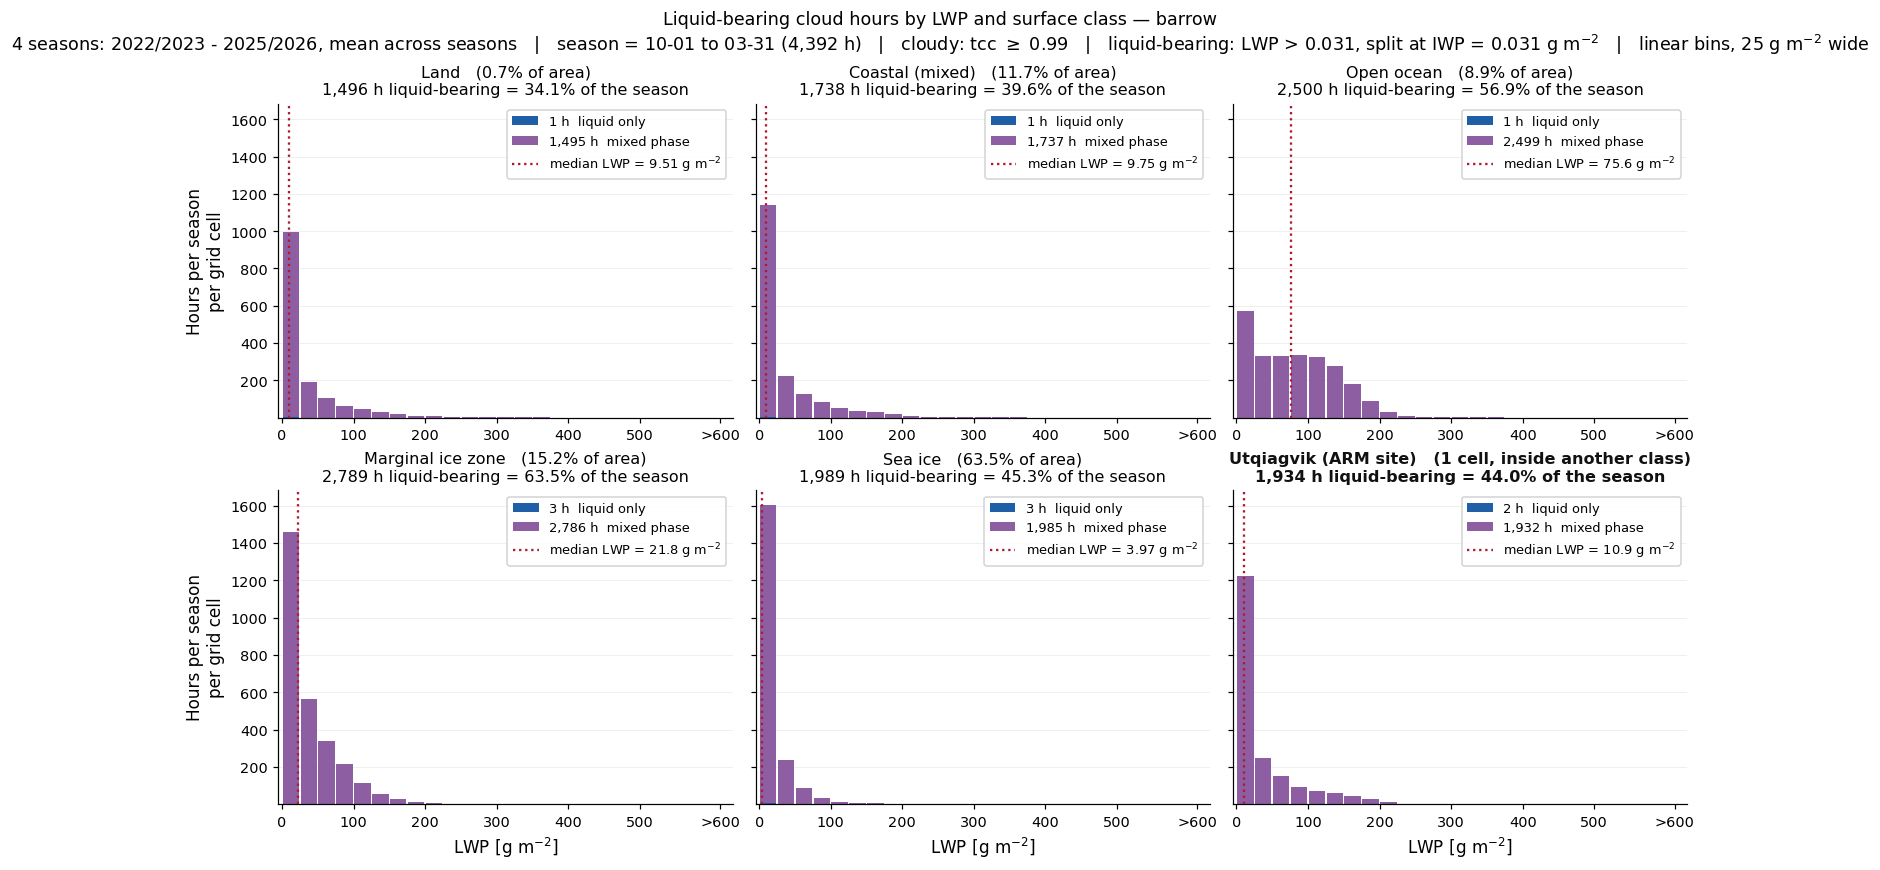

In [4]:
lwph.fig_linear(A, out_dir=SAVE_DIR);

### 2. Log-spaced LWP bins

The same hours over log-spaced bins, which resolves the low-LWP end where the
midwinter population lives. Leftmost bar is the underflow, rightmost the
overflow, so nothing is dropped relative to figure 1.

  -> figures/barrow_lwp_hist_surfaceclass_log_mean2022-2025.png


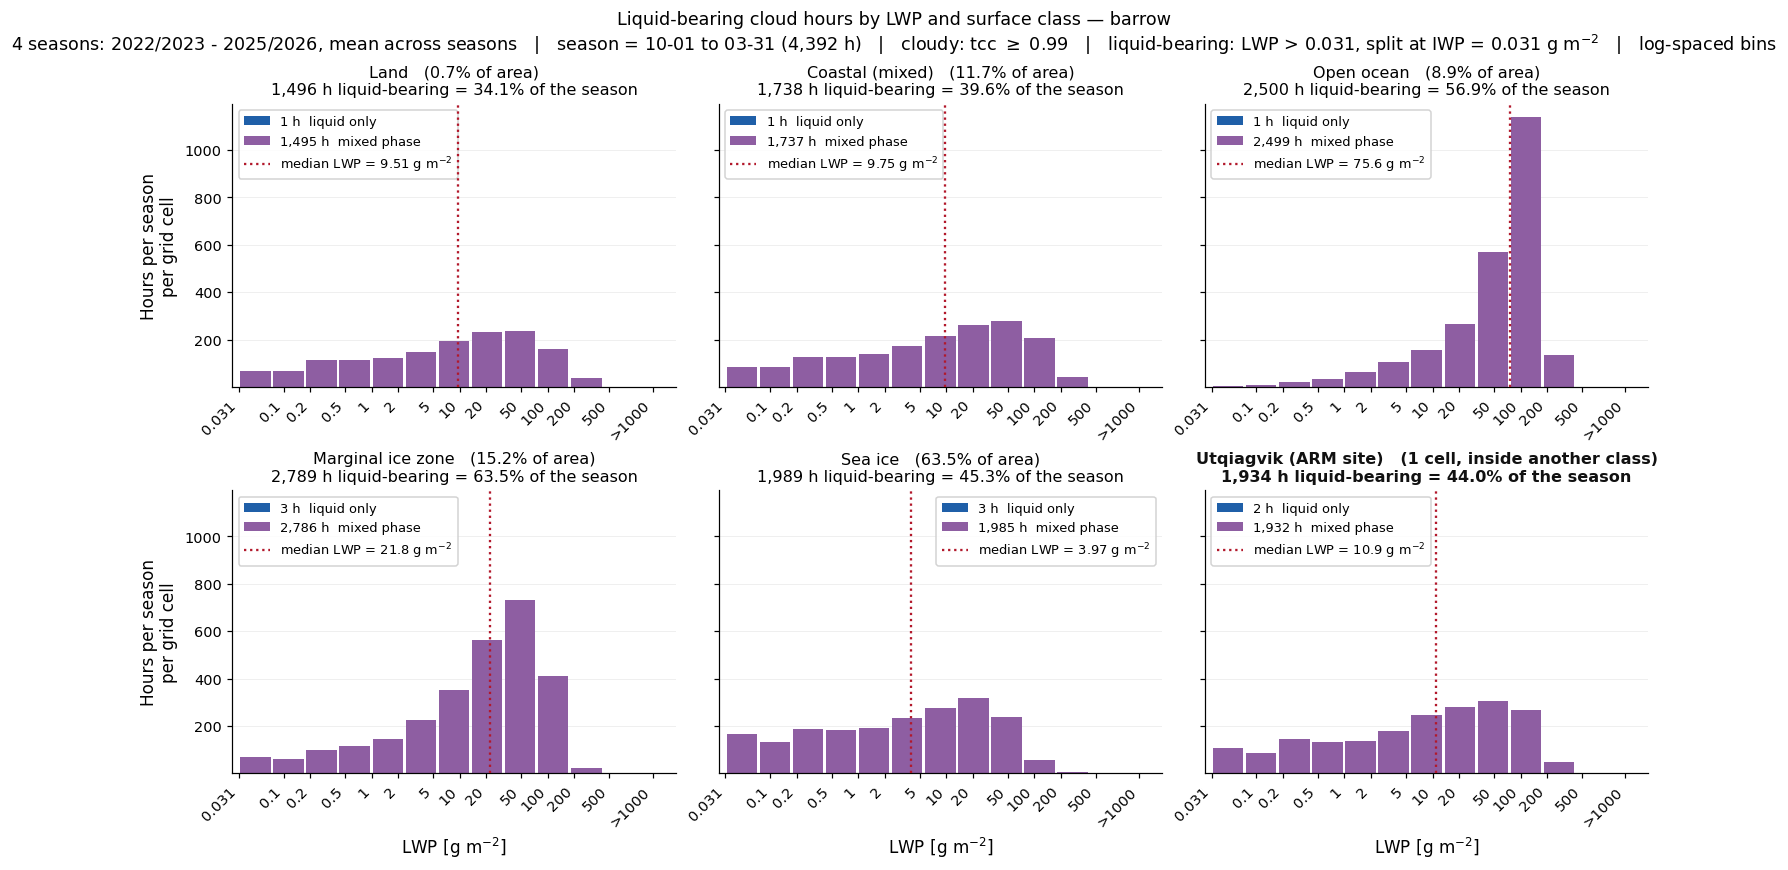

In [5]:
lwph.fig_log(A, out_dir=SAVE_DIR);

## Redraw everything

Same set the command-line run writes.

  -> figures/barrow_lwp_hist_surfaceclass_linear_mean2022-2025.png
  -> figures/barrow_lwp_hist_surfaceclass_log_mean2022-2025.png


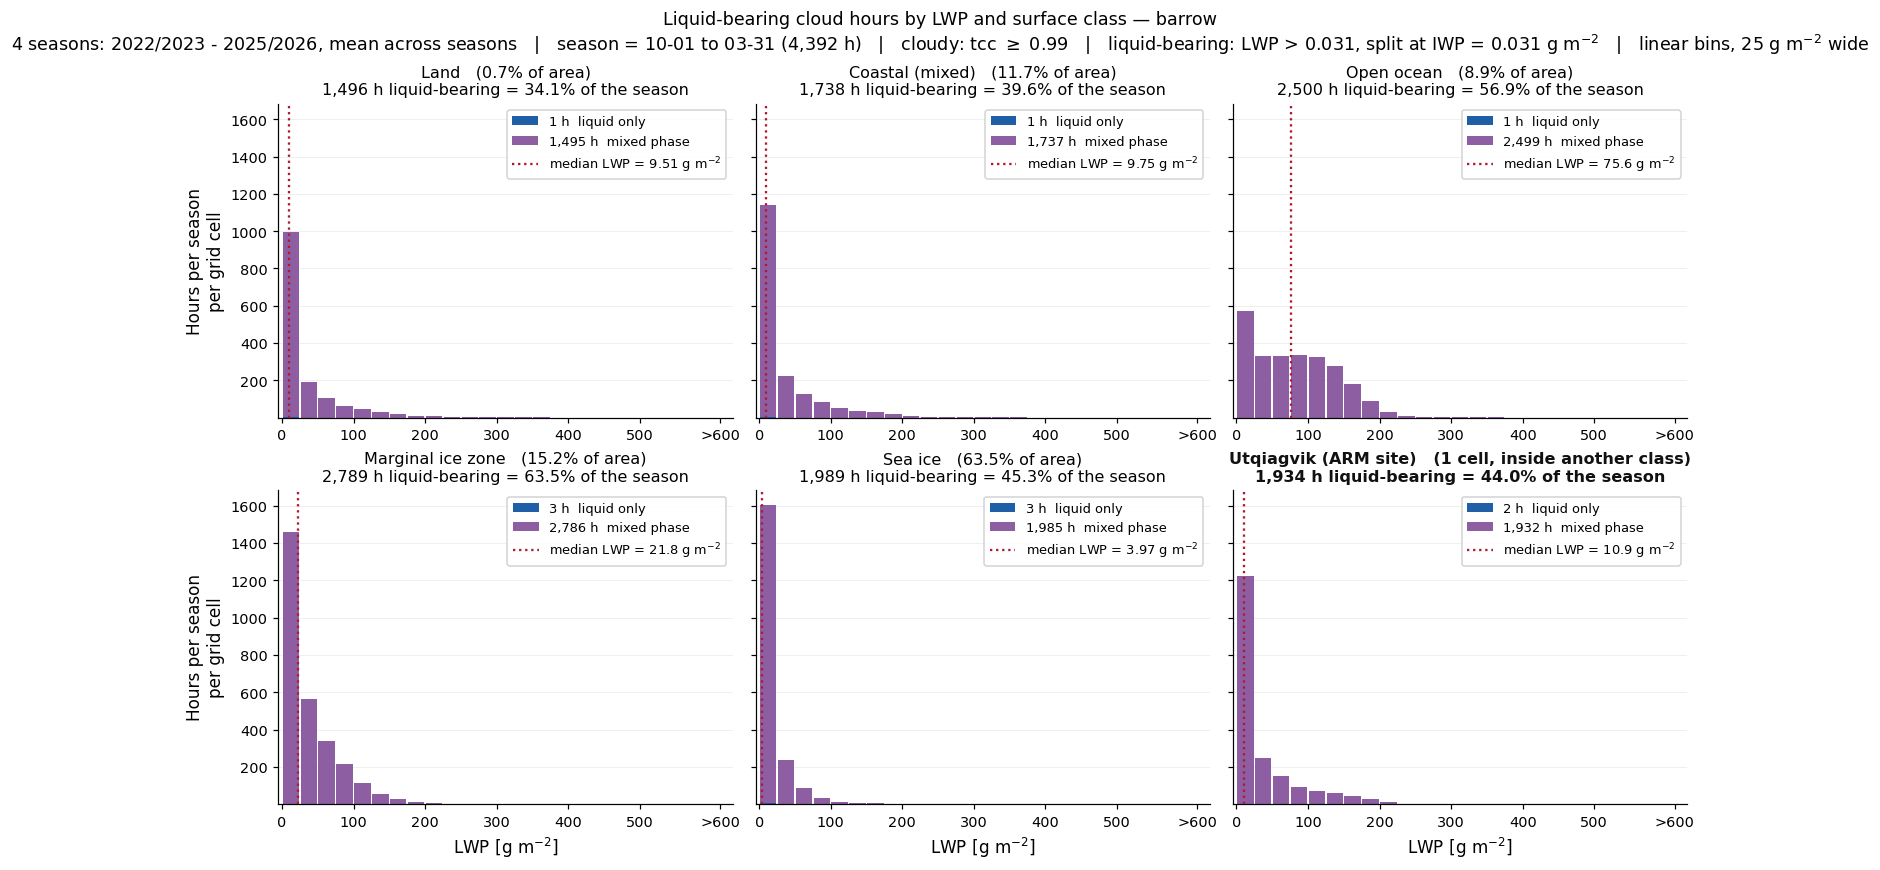

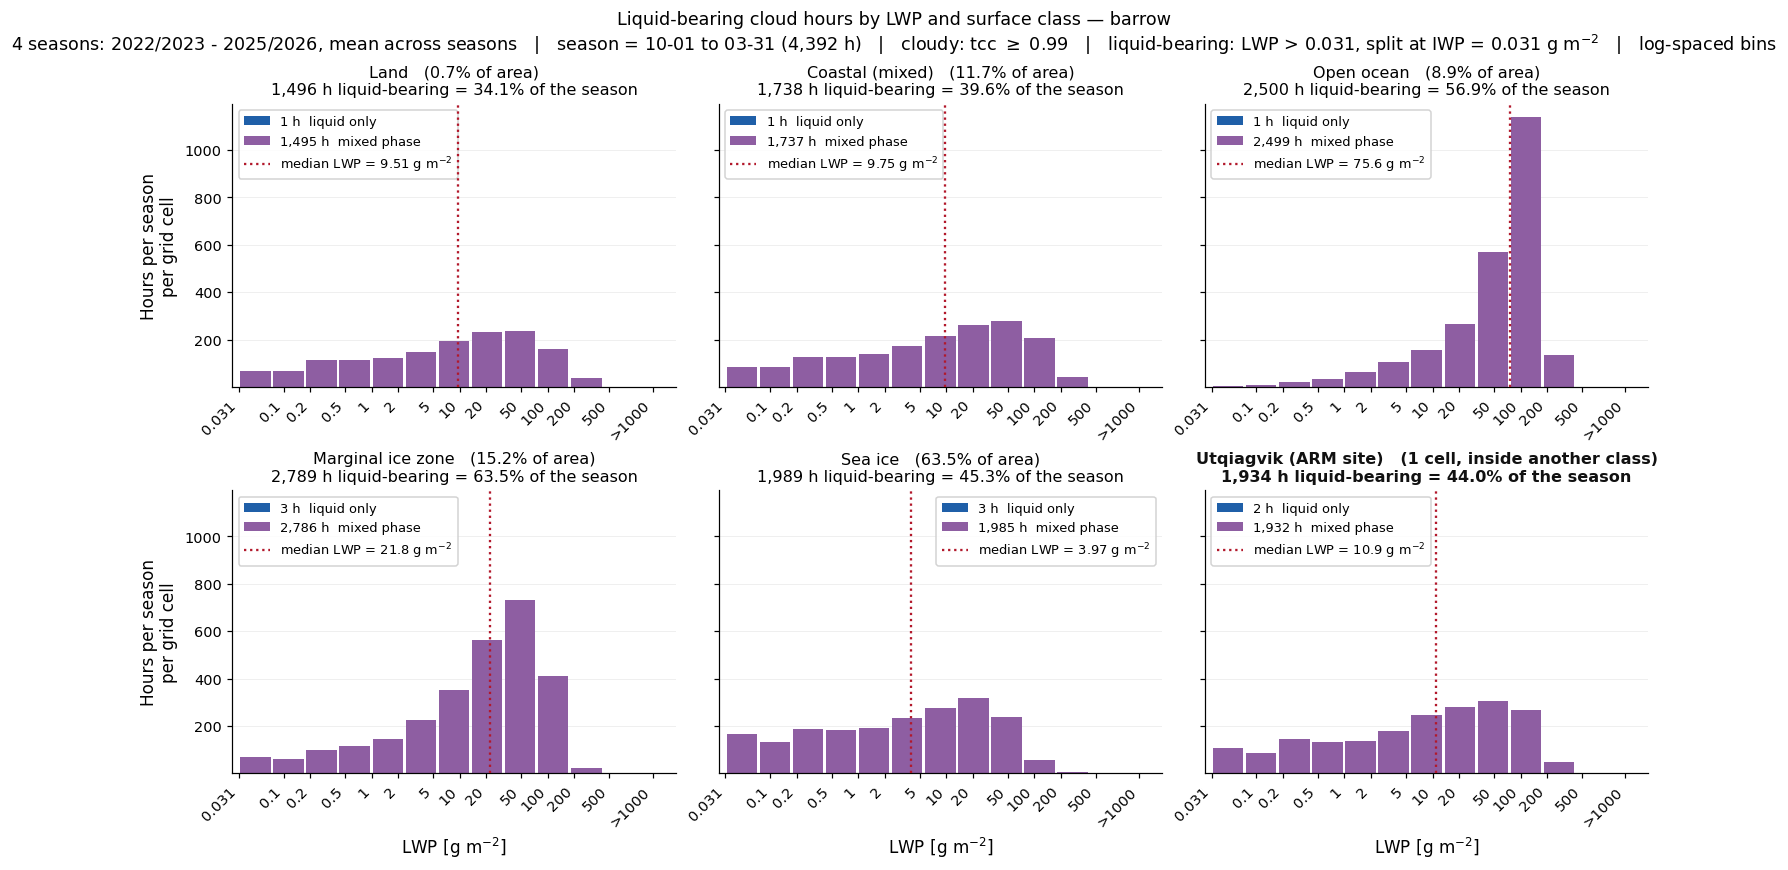

In [6]:
for fn in lwph.ALL_FIGURES:
    fn(A, out_dir=SAVE_DIR);

## Changing options

Anything that alters what is loaded, classified, or binned -- region, years,
season window, phase thresholds, cloud-cover gate, bin edges -- needs a fresh
`prepare()`, because the histograms are accumulated during the streaming pass:

```python
# a threshold near a microwave radiometer's detection floor
A_mwr = lwph.prepare(region="barrow", years=(2019, 2020), lwp_min=25.0)
lwph.fig_log(A_mwr)

# midwinter only
A_djf = lwph.prepare(region="barrow", years=(2019, 2020),
                     season_start=(12, 1), season_end=(2, 28))
lwph.fig_linear(A_djf)
```

Options that only affect DRAWING can be changed on the existing `A` without
reloading, since the figures read them at draw time:

```python
A.args.y_scale = "log"      # hours axis, for the high-LWP tail
lwph.fig_linear(A)

A.args.layout = (3, 2)
lwph.fig_log(A)
```

Note `bin_scale` is a command-line convenience only: `prepare()` fills both
scales either way, so in a notebook just call the figure you want.